<a href="https://colab.research.google.com/github/KAJAL-25/Blinklytics/blob/main/Gas_turbine_Energy_Yield_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(1)
])

print("Model created successfully")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model created successfully


In [ ]:
from google.colab import files
uploaded=files.upload
df = pd.read_csv("gas_turbines.csv")


In [ ]:
df.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,6.8594,1007.9,96.799,3.5000,19.663,1059.2,550.00,114.70,10.605,3.1547,82.722
1,6.7850,1008.4,97.118,3.4998,19.728,1059.3,550.00,114.72,10.598,3.2363,82.776
2,6.8977,1008.8,95.939,3.4824,19.779,1059.4,549.87,114.71,10.601,3.2012,82.468
3,7.0569,1009.2,95.249,3.4805,19.792,1059.6,549.99,114.72,10.606,3.1923,82.670
4,7.3978,1009.7,95.150,3.4976,19.765,1059.7,549.98,114.72,10.612,3.2484,82.311


In [ ]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15039 entries, 0 to 15038
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      15039 non-null  float64
 1   AP      15039 non-null  float64
 2   AH      15039 non-null  float64
 3   AFDP    15039 non-null  float64
 4   GTEP    15039 non-null  float64
 5   TIT     15039 non-null  float64
 6   TAT     15039 non-null  float64
 7   TEY     15039 non-null  float64
 8   CDP     15039 non-null  float64
 9   CO      15039 non-null  float64
 10  NOX     15039 non-null  float64
dtypes: float64(11)
memory usage: 1.3 MB


,0
AT,0
AP,0
AH,0
AFDP,0
GTEP,0
TIT,0
TAT,0
TEY,0
CDP,0
CO,0


In [ ]:
X_ambient=df[["AT", "AP", "AH"]]
Y=df["TEY"]

In [ ]:
print(df.columns)

Index(['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO',
       'NOX'],
      dtype='object')


In [ ]:
X_all=df.drop("TEY", axis=1)

In [ ]:
X_train_a, X_test_a, Y_train, Y_test = train_test_split ( X_ambient, Y , test_size=0.2, random_state=42 )
X_train_all, X_test_all, Y_train, Y_test = train_test_split ( X_all, Y, test_size=0.2, random_state=42)

In [ ]:
scaler_a = StandardScaler()
X_train_a = scaler_a.fit_transform(X_train_a)
X_test_a = scaler_a.transform(X_test_a)

scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(X_train_all)
X_test_all = scaler_all.transform(X_test_all)

In [ ]:
lr=LinearRegression()
lr.fit(X_train_all, Y_train)

Y_pred_lr=lr.predict(X_train_all)
print("Linear Regression R2:", r2_score, (Y_test, Y_pred_lr))


Linear Regression R2: <function r2_score at 0x7f5c2ac6d120> (13312    134.46
12627    111.88
6393     133.72
4990     133.79
12462    110.77
          ...  
11478    119.25
12302    133.74
13093    146.31
2699     150.07
12506    111.77
Name: TEY, Length: 3008, dtype: float64, array([109.67434467, 133.93205799, 160.34189989, ..., 109.99967635,
       113.02344996, 132.51311362]))


In [ ]:
def build_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_all = build_model(X_train_all.shape[1])

history_all = model_all.fit(
    X_train_all,
    Y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


301/301 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9397.5391 - mae: 81.4320 - val_loss: 228.8277 - val_mae: 11.3259
Epoch 2/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 348.1377 - mae: 14.6198 - val_loss: 124.8460 - val_mae: 8.1781
Epoch 3/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 256.7810 - mae: 12.5614 - val_loss: 70.0588 - val_mae: 5.7164
Epoch 4/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 212.2518 - mae: 11.5182 - val_loss: 44.5578 - val_mae: 4.3997
Epoch 5/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 177.0034 - mae: 10.5309 - val_loss: 29.3706 - val_mae: 3.8273
Epoch 6/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 162.4824 - mae: 10.0789 - val_loss: 18.7521 - val_mae: 3.0343
Epoch 7/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 152.7730 - mae: 9.8225 - val_loss: 13.8451 - val_mae: 2.5205
Epoch 8/200
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 139.0817 - mae: 9.3727 - val_loss: 10.8409 - val_mae: 2.3666
Epoch 9/200
301/301 ━━━━

In [ ]:
Y_pred_nn = model_all.predict(X_test_all)

print("Neural Network R2:", r2_score(Y_test, Y_pred_nn))
print("MAE:", mean_absolute_error(Y_test, Y_pred_nn))
print("MSE:", mean_squared_error(Y_test, Y_pred_nn))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Neural Network R2: 0.993935933197901
MAE: 0.9823516682361035
MSE: 1.5183793684175153


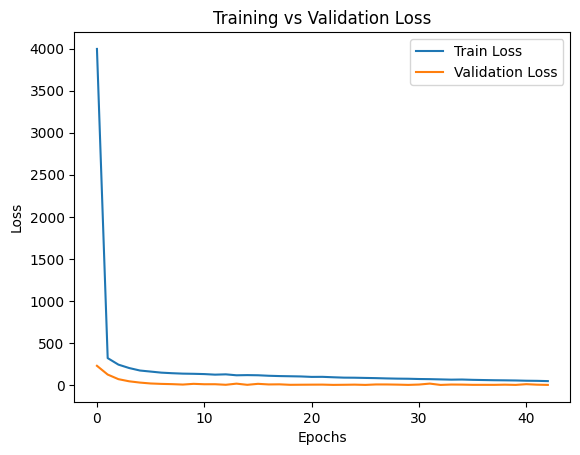

In [ ]:
plt.plot(history_all.history['loss'])
plt.plot(history_all.history['val_loss'])
plt.legend(['Train Loss', 'Validation Loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

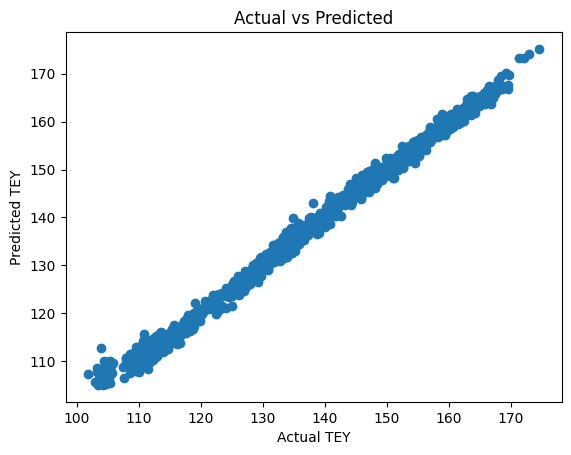

In [ ]:
plt.scatter(Y_test, Y_pred_nn)
plt.xlabel("Actual TEY")
plt.ylabel("Predicted TEY")
plt.title("Actual vs Predicted")
plt.show()

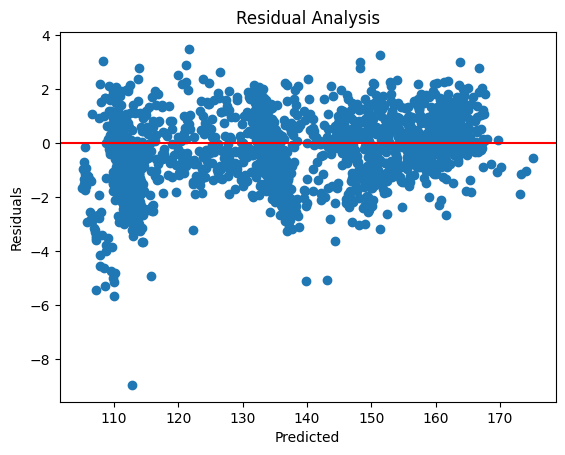

In [ ]:
residuals = Y_test - Y_pred_nn.flatten()

plt.scatter(y_pred_nn, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

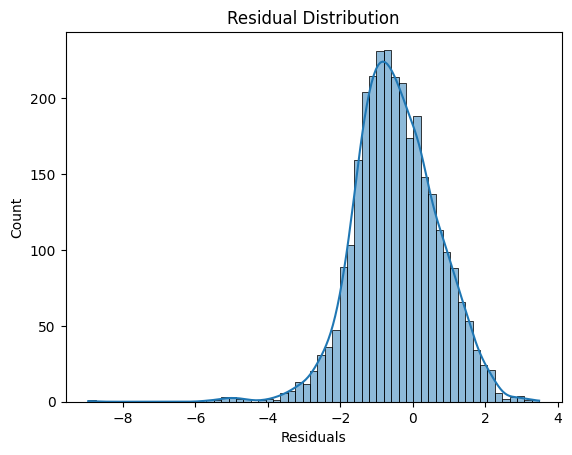

In [ ]:
residuals = Y_test - _pred_nn.flatten()

plt.figure()
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Residual Distribution")
plt.show()

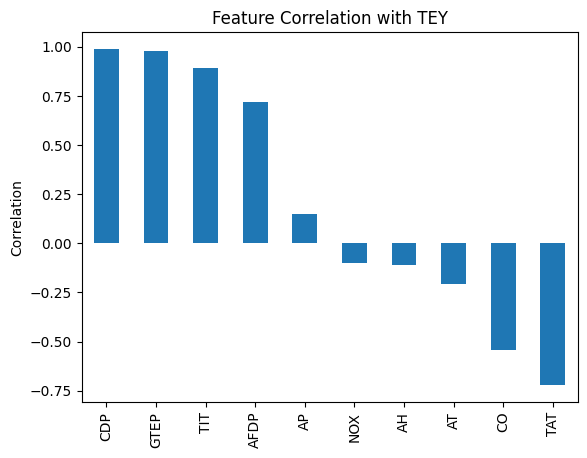

In [ ]:
correlation = df.corr()["TEY"].sort_values(ascending=False)

plt.figure()
correlation.drop("TEY").plot(kind="bar")
plt.title("Feature Correlation with TEY")
plt.ylabel("Correlation")
plt.show()